# Базовая трёхпараметрическая модель SIR

Поток заражения разделён на вероятность передачи `beta` и среднее число
контактов `c`. Это позволяет интерпретировать санитарные меры независимо.

In [1]:
using DrWatson
@quickactivate "BasicModelsLab"
using BasicModelsLab.BasicModels
using CSV, DataFrames, JLD2, LaTeXStrings, Plots, Statistics

script_name = "sir_ode"
mkpath(datadir(script_name))
mkpath(plotsdir(script_name))
gr()

Plots.GRBackend()

## Условия эксперимента

In [2]:
u0 = [990.0, 10.0, 0.0]
p = [0.05, 10.0, 0.25] # beta, contacts, gamma
tspan = (0.0, 40.0)
saveat = 0.1
R0_basic = p[1] * p[2] / p[3]

solution = solve_sir(; u0, p, tspan, saveat)
sir = sir_dataframe(solution)
sir.Re = R0_basic .* sir.S ./ sir.N
peak_index = argmax(sir.I)
peak_time = sir.t[peak_index]
peak_value = sir.I[peak_index]
threshold = 100 * (1 - 1 / R0_basic)

CSV.write(datadir(script_name, "sir_trajectory.csv"), sir)
summary = DataFrame(
    metric=["R0", "peak_infected", "peak_time", "final_recovered", "population_error"],
    value=[R0_basic, peak_value, peak_time, sir.R[end], maximum(abs.(sir.N .- sir.N[1]))],
)
CSV.write(datadir(script_name, "sir_summary.csv"), summary)
@save datadir(script_name, "sir_solution.jld2") u0 p tspan solution sir summary

println("SIR: beta=$(p[1]), c=$(p[2]), gamma=$(p[3]), R0=$(round(R0_basic, digits=3))")
println("Peak I=$(round(peak_value, digits=2)) at t=$(round(peak_time, digits=2)) days")
println("R(40)=$(round(sir.R[end], digits=2)); population error=$(summary.value[end])")

SIR: beta=0.05, c=10.0, gamma=0.25, R0=2.0


Peak I=158.45 at t=17.5 days
R(40)=775.69; population error=6.821210263296962e-13


## Семь представлений динамики

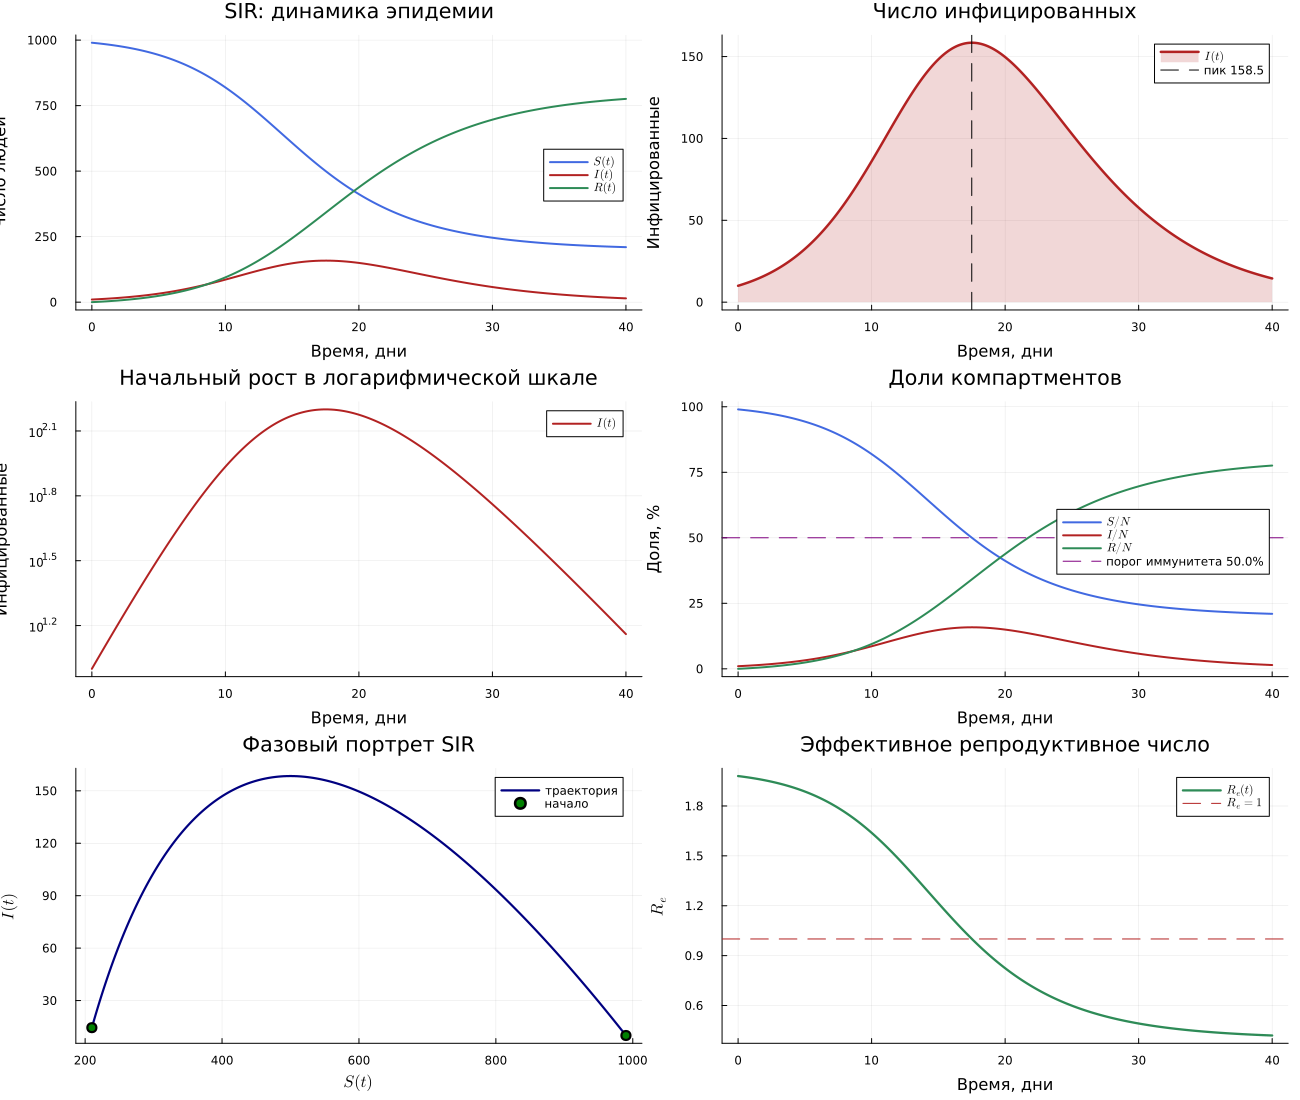

In [3]:
main_plot = plot(sir.t, [sir.S sir.I sir.R];
    label=[L"S(t)" L"I(t)" L"R(t)"], xlabel="Время, дни",
    ylabel="Число людей", title="SIR: динамика эпидемии", lw=2,
    color=[:royalblue :firebrick :seagreen], size=(900, 520), legend=:right)

infected_plot = plot(sir.t, sir.I; label=L"I(t)", xlabel="Время, дни",
    ylabel="Инфицированные", title="Число инфицированных", color=:firebrick,
    lw=2.5, fill=(0, 0.18, :firebrick), size=(900, 440))
vline!(infected_plot, [peak_time]; label="пик $(round(peak_value, digits=1))",
       color=:black, ls=:dash)

log_plot = plot(sir.t, sir.I; label=L"I(t)", xlabel="Время, дни",
    ylabel="Инфицированные", title="Начальный рост в логарифмической шкале",
    yscale=:log10, color=:firebrick, lw=2, size=(900, 440))

percentage_plot = plot(sir.t, 100 .* Matrix(select(sir, [:S, :I, :R])) ./ sir.N;
    label=[L"S/N" L"I/N" L"R/N"], xlabel="Время, дни", ylabel="Доля, %",
    title="Доли компартментов", lw=2, color=[:royalblue :firebrick :seagreen],
    size=(900, 520), legend=:right)
hline!(percentage_plot, [threshold]; label="порог иммунитета $(round(threshold, digits=1))%",
       color=:purple, ls=:dash)

phase_plot = plot(sir.S, sir.I; label="траектория", xlabel=L"S(t)", ylabel=L"I(t)",
    title="Фазовый портрет SIR", color=:navy, lw=2.2, size=(820, 540))
scatter!(phase_plot, [sir.S[1], sir.S[end]], [sir.I[1], sir.I[end]];
         label=["начало" "t=40"], color=[:green :black], ms=5)

effective_plot = plot(sir.t, sir.Re; label=L"R_e(t)", xlabel="Время, дни",
    ylabel=L"R_e", title="Эффективное репродуктивное число", color=:seagreen,
    lw=2.3, size=(900, 440))
hline!(effective_plot, [1.0]; label=L"R_e=1", color=:firebrick, ls=:dash)

panel = plot(main_plot, infected_plot, log_plot, percentage_plot,
             phase_plot, effective_plot; layout=(3, 2), size=(1300, 1100))

for (plot_object, filename) in [
    (main_plot, "sir_main.png"), (infected_plot, "sir_infected.png"),
    (log_plot, "sir_log_scale.png"), (percentage_plot, "sir_percentages.png"),
    (phase_plot, "sir_phase_portrait.png"), (effective_plot, "sir_effective_R.png"),
    (panel, "sir_panel.png")]
    savefig(plot_object, plotsdir(script_name, filename))
end

display(panel)